<a href="https://colab.research.google.com/github/Mikhailo88/MN-TrenNotes-K4/blob/main/Copy_of_%D0%9B%D0%B5%D0%BA%D1%86%D1%96%D1%8F_%D0%9C%D0%9D_%D0%A0%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%96%D1%8F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Завдання 1. Лінійна регресія
# Використати sklearn для побудови простої лінійної регресії на синтетичних даних.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import seaborn as sns
import math

# Дані
np.random.seed(42)
X = np.linspace(0, 10, 50).reshape(-1, 1)
y = 3 * X.flatten() + 7 + np.random.normal(0, 3, size=50)

# Модель
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

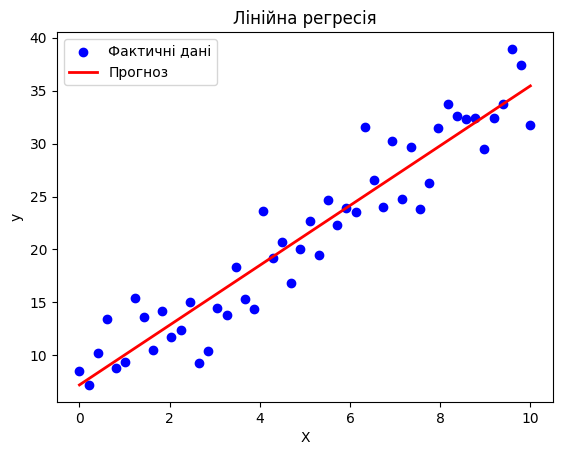

Коефіцієнт w: 2.826049801524533
Зсув b: 7.193329276608916


In [2]:
# Візуалізація
plt.scatter(X, y, color="blue", label="Фактичні дані")
plt.plot(X, y_pred, color="red", linewidth=2, label="Прогноз")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Лінійна регресія")
plt.legend()
plt.show()

print("Коефіцієнт w:", model.coef_[0])
print("Зсув b:", model.intercept_)

In [3]:
# Завдання 2. Метрики оцінювання моделі
# Обчислити MSE, RMSE, MAE, MAPE та R² для моделі.

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y, y_pred)

rmse = np.sqrt(mse)

mae = mean_absolute_error(y, y_pred)

mape = np.mean(np.abs((y - y_pred) / y)) * 100


r2 = r2_score(y, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("MAPE:", mape, "%")
print("R²:", r2)

MSE: 7.4262761560004185
RMSE: 2.7251194755460575
MAE: 2.2235308318513334
MAPE: 12.422165424725202 %
R²: 0.9031743908043622


In [4]:
# Завдання 3. Недонавчання та перенавчання
# Порівняти якість моделей з різними ступенями поліноміальної регресії.

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split

# Генерація даних
np.random.seed(0)
X = np.linspace(-3, 3, 50).reshape(-1, 1)
y = np.sin(X).flatten() + np.random.normal(0, 0.2, size=50)

# Розбиття на train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Перевірка моделей різної складності
degrees = [1, 4, 9]
for d in degrees:
    model = make_pipeline(PolynomialFeatures(d), LinearRegression())
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    print(f"\nПоліном {d}-го ступеня")
    print("R² (train):", r2_score(y_train, y_train_pred))
    print("R² (test):", r2_score(y_test, y_test_pred))


Поліном 1-го ступеня
R² (train): 0.5264113966340865
R² (test): 0.3547443589594206

Поліном 4-го ступеня
R² (train): 0.8991971371894268
R² (test): 0.9088792255171657

Поліном 9-го ступеня
R² (train): 0.9121613336710932
R² (test): 0.9060769866142218


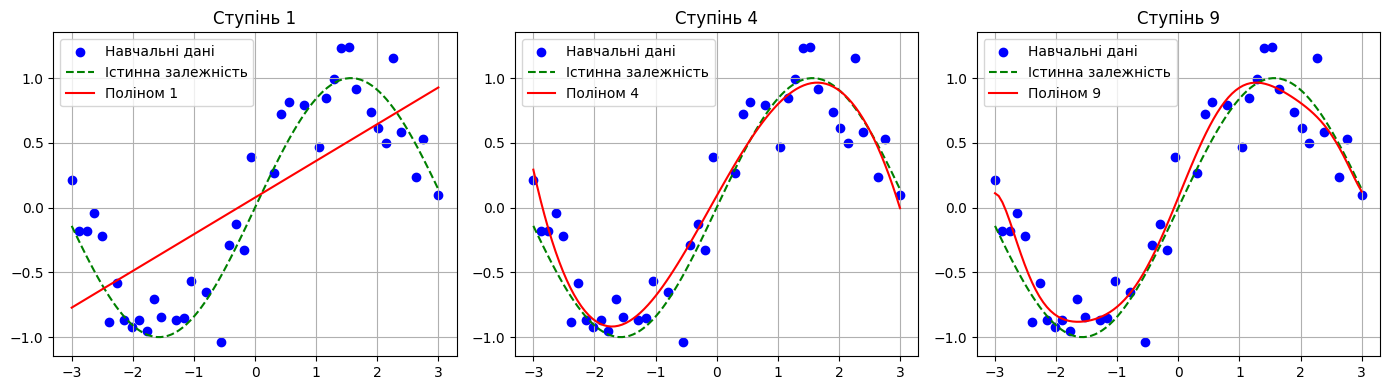

In [5]:
# Завдання 4. Візуалізація перенавчання
# Побудувати графіки для наочності.

plt.figure(figsize=(14, 4))
for i, d in enumerate(degrees):
    model = make_pipeline(PolynomialFeatures(d), LinearRegression())
    model.fit(X_train, y_train)
    X_plot = np.linspace(-3, 3, 100).reshape(-1, 1)
    y_plot = model.predict(X_plot)

    plt.subplot(1, 3, i + 1)
    plt.scatter(X_train, y_train, color="blue", label="Навчальні дані")
    plt.plot(X_plot, np.sin(X_plot), color="green", linestyle="--", label="Істинна залежність")
    plt.plot(X_plot, y_plot, color="red", label=f"Поліном {d}")
    plt.title(f"Ступінь {d}")
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

In [7]:
# Завдання 5.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR

In [8]:
df = load_diabetes()

X = pd.DataFrame(df.data, columns=df.feature_names)
y = pd.Series(df.target, name="target")

In [9]:
df = X.copy()
df["target"] = y

In [10]:
df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


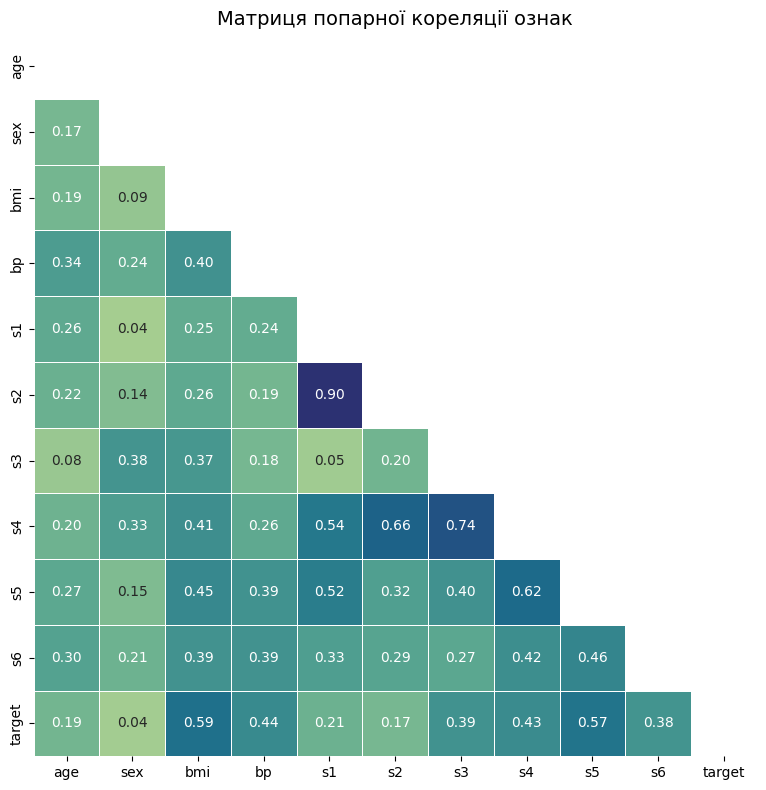

In [14]:
mtx = df.corr(numeric_only=True).abs()

# Побудова теплової карти кореляції
fig, ax = plt.subplots(figsize=(8, 8))

sns.heatmap(
    mtx,
    cmap='crest',
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    mask=np.triu(np.ones_like(mtx, dtype=bool)),  # маскуємо верхній трикутник
    square=True,
    cbar=False,
    ax=ax
)

plt.title("Матриця попарної кореляції ознак", fontsize=14)
plt.tight_layout()
plt.show()

In [15]:
# Виведення кореляцій з цільовою змінною 'target'
correlation_with_class = df.corr()['target'].sort_values(ascending=False)
correlation_with_class

,target
target,1.000000
bmi,0.586450
s5,0.565883
bp,0.441482
s4,0.430453
s6,0.382483
s1,0.212022
age,0.187889
s2,0.174054
sex,0.043062


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

X_train.shape, X_test.shape

((331, 10), (111, 10))


Цей набір даних входить у стандартні бібліотеки scikit-learn (sklearn.datasets). Він був зібраний у 1990-х роках і часто використовується як навчальний приклад для задач регресії.

**Загальна характеристика**

Кількість об’єктів (спостережень): 442 пацієнти.

Кількість ознак (features): 10 кількісних предикторів.

Цільова змінна: прогресування діабету (кількісна оцінка стану через рік).

**Ознаки**

Дані зберігаються у вигляді матриці X розміру (442 × 10). Кожна ознака була центрованою і нормалізованою (середнє = 0, стандартне відхилення = 1).

Ознаки (feature_names):

age — вік пацієнта;

sex — стать (0 = жіноча, 1 = чоловіча, але після нормалізації це вже безрозмірне число);

bmi — індекс маси тіла;

bp — середній артеріальний тиск;

s1 — рівень загального холестерину;

s2 — рівень ЛПНЩ (low-density lipoproteins);

s3 — рівень ЛПВЩ (high-density lipoproteins);

s4 — рівень тригліцеридів (logarithmized);

s5 — рівень цукру в крові;

s6 — рівень інсуліну в крові.

In [17]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [18]:
r2 = r2_score(y_test, y_pred)
r2

0.4849058889476756

In [19]:
mae = mean_absolute_error(y_test, y_pred)
mae

41.54850685988061

In [20]:
mse = mean_squared_error(y_test, y_pred)
mse

2848.3106508475053

In [21]:
models = {
    "LinearRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0, random_state=42))
    ]),
    "Lasso": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.001, max_iter=20000, random_state=42))
    ]),
    "ElasticNet": Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=20000, random_state=42))
    ]),
    "SVR_RBF": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR(kernel="rbf", C=10.0, epsilon=0.1))
    ]),
}

In [22]:
predictions = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test).ravel()
    predictions[name] = y_pred

    r2  = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)

    print(f"\n=== {name} ===")
    print(f"R² : {r2:.4f}")
    print(f"MAE: {mae:.3f}")
    print(f"MSE: {mse:.3f}")


=== LinearRegression ===
R² : 0.4849
MAE: 41.549
MSE: 2848.311

=== Ridge ===
R² : 0.4859
MAE: 41.507
MSE: 2842.835

=== Lasso ===
R² : 0.4849
MAE: 41.548
MSE: 2848.195

=== ElasticNet ===
R² : 0.4851
MAE: 41.540
MSE: 2846.990

=== SVR_RBF ===
R² : 0.5126
MAE: 41.334
MSE: 2695.180


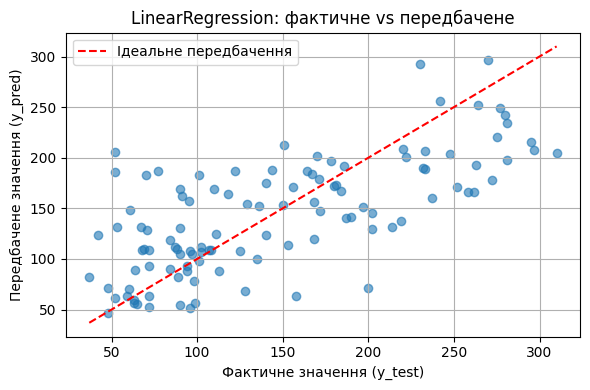

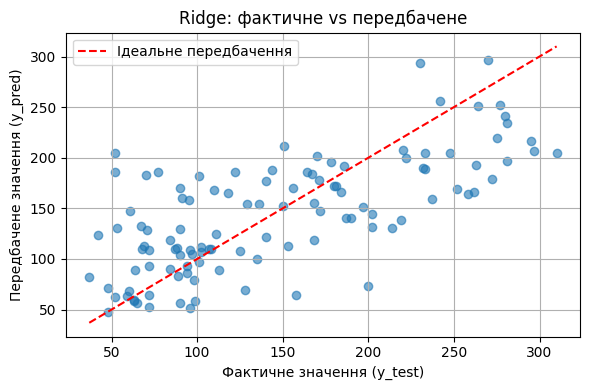

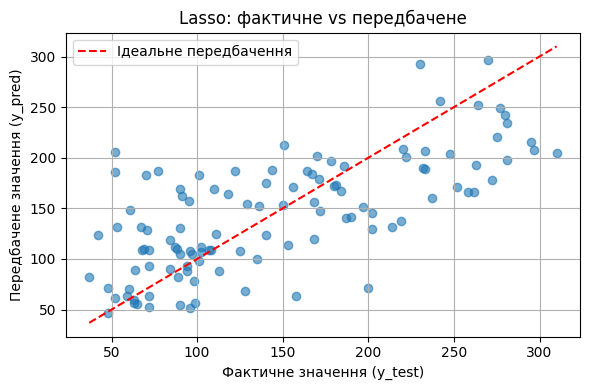

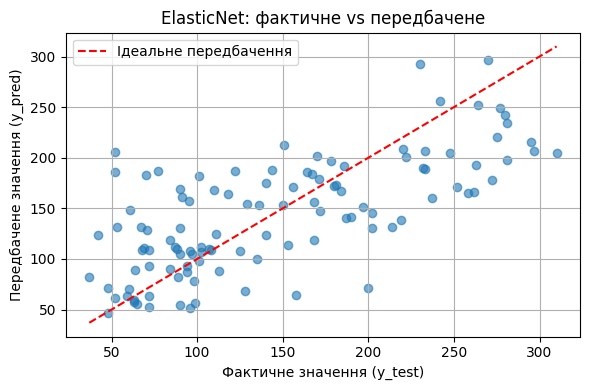

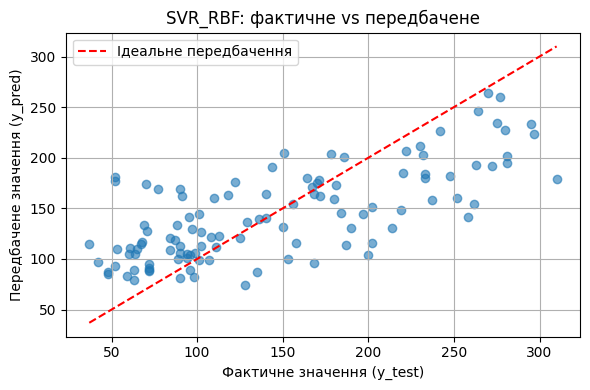

In [23]:
y_true = np.asarray(y_test).ravel()
y_min = min([y_true.min()] + [p.min() for p in predictions.values()])
y_max = max([y_true.max()] + [p.max() for p in predictions.values()])

for name, y_pred in predictions.items():
    plt.figure(figsize=(6, 4))
    plt.scatter(y_true, y_pred, alpha=0.6)  # без edgecolors, щоб уникнути warning
    plt.plot([y_min, y_max], [y_min, y_max], 'r--', label='Ідеальне передбачення')
    plt.xlabel("Фактичне значення (y_test)")
    plt.ylabel("Передбачене значення (y_pred)")
    plt.title(f"{name}: фактичне vs передбачене")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()